# Notebook 02 — Beat Averaging and Clustering Across All Animals

**Project:** Reproducible Signal Processing and Multivariate Analysis of Preclinical Mouse ECG Data for Cardiotoxicity Detection  
**Author:** Vishvasundar (MSc, University College Cork)  
**Supervisors:** Dr Luke Kelly (Statistics), Dr Roisin Kelly-Laubscher (Pharmacology)

## What this notebook does

Process every `.txt` ECG export in `data/`, isolate each animal's clean baseline window, detect R peaks, build an averaged-beat template, extract morphology features, and cluster the animals. Final outputs: `outputs/all_animals_features.csv` and four PNG figures.

### Annotation rule (Fix 1)
Annotations are matched generously by *prefix character* (`#*`, `#3`, `#1`) and the **gap between paired markers must be 10–120 s**. If the only candidate pair is too long (e.g. a 15-minute baseline), the first 60 s after the start marker is used. If only a single marker exists, a 30 s window after it is used. Non-baseline procedure markers (containing `oc`, `jugular`, `jugcan`) are excluded.

### ECG column rule (Fix 2)
The LabChart header tells us how many channels exist and which is *Channel 3*. The number of leading time columns is computed dynamically from `n_cols_in_first_data_row − n_channels`. Channel 3 is always the ECG. A sanity check rejects any column whose values look like BPM (300–700) instead of mV (±15).

### Filtering — Adaptive Physiology-Driven Framework
Butterworth bandpass **0.5–150 Hz** (zero-phase `filtfilt`). The high cutoff is raised from the human-ECG-standard 40 Hz to **150 Hz** because the mouse QRS is only ~10 ms wide and carries spectral energy well above 40 Hz; 150 Hz preserves the sharp QRS/J-wave morphology and is safely below the 500 Hz Nyquist (1 kHz sampling).

### Robust R-peak detection (Fix 3)
`height = median + 4 × MAD` (median absolute deviation), so big artifact spikes do not raise the threshold above the real ~0.2 mV R peaks; `prominence = max(0.3 × MAD, 0.005 mV)`. The refractory **distance = `REFRACTORY_MS` (55 ms)** — the absolute physiological minimum between successive R peaks (matches Notebook 01); `MIN_RR_MS` (75 ms) is kept as a physiological RR-plausibility floor. If the resulting heart rate is outside 300–700 bpm we retry on the inverted signal. Files still outside 300–700 bpm are flagged `NEEDS_REVIEW` and kept in the audit list.

### QTc formula
**Mitchell:** `QTc = QT / √(RR/100)`, with QT and RR in milliseconds. This is the mouse-specific correction confirmed by Roisin. The output CSV carries an explicit `qtc_formula` column (value `Mitchell`) documenting which formula was applied.

> ⚠️ **OPEN ISSUE — QT measurement method differs between Notebook 01 and Notebook 02 (do not resolve yet; needs supervisor input).**
>
> The **QTc formula is identical** in both notebooks, but the **QT input differs** because of how each notebook measures the QT interval:
> - **Notebook 01:** QT measured **per beat** on the raw filtered baseline signal, then averaged.
> - **Notebook 02 (this notebook):** QT measured on the **4-beat averaged template** (return-to-baseline within a fixed window).
>
> Same animal, same formula — the difference is purely the QT measurement method. Robust QT-endpoint detection in mouse ECG is genuinely hard (T wave merges with the J wave, no clean isoelectric return), so this is **deliberately left unresolved** pending input from Dr Kelly-Laubscher / Dr Kelly. Do **not** change the QT method until that discussion has happened.

### Scale (Fix 4)
No animal IDs are hardcoded. The pipeline iterates every `*.txt` file in the data folder. Each file is wrapped in `try/except` so one bad file cannot crash the run.

## Setup — imports and project paths

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks, iirnotch
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster

# Path detection is automatic — no manual changes needed.
# Clone the repo, open the notebook, and run.
from pathlib import Path

# Automatically detect project root — works on any machine
# Place this notebook inside the project folder for auto-detection
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'data').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR    = PROJECT_ROOT / 'data'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'

# Create output folders if they don't exist
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FS                  = 1000
BANDPASS_LOW_HZ     = 0.5
BANDPASS_HIGH_HZ    = 150.0      # Adaptive Physiology-Driven Framework: raised 40 -> 150 Hz
BANDPASS_ORDER      = 2

# --- R-peak timing (Adaptive Physiology-Driven Framework) -----------------
REFRACTORY_MS       = 55         # find_peaks refractory distance (ms): min between
                                 # successive R peaks. Drives the detector distance.
                                 # Refractory period of 55 ms validated against supervisor
                                 # LabChart analysis (Kelly-Laubscher, 2024) confirming
                                 # mean HR > 500 bpm under 1.5% isoflurane.
MIN_RR_MS           = 75         # physiological minimum plausible RR (ms); ~max 800 bpm.
                                 # Reserved as an RR-plausibility floor (not the distance).
BEATS_TO_AVERAGE    = 4
PRE_R_MS            = 100
POST_R_MS           = 150

HR_NORMAL_LOW       = 400        # green/red on the bar chart
HR_NORMAL_HIGH      = 500
HR_ACCEPT_LOW       = 300        # used by the R-peak retry logic
HR_ACCEPT_HIGH      = 700

GAP_MIN_S           = 10         # minimum baseline-window length
GAP_MAX_S           = 120        # maximum 'short' baseline-window length
GAP_MAX_LONG_S      = 900        # accept up to 15 min for explicit 'baseline' markers
LONG_USE_S          = 60         # of a long window, only use the first 60 s
SINGLE_FALLBACK_S   = 30         # if only a start marker, use 30 s after it

EXCLUDE_KEYWORDS    = ("oc 1", "oc 2", "oc1", "oc2",
                       "jugular", "jugcan", "injection", "inject")
END_KEYWORDS        = ("end", "done", "stop")
START_HINTS         = ("baseline", "ecg", "start")

print(f"Data folder   : {DATA_DIR}")
print(f"Output folder : {OUTPUTS_DIR}")
print(f"Figure folder : {FIGURES_DIR}")

Data folder   : C:\Users\Vishva\Downloads\ecg_cardiotoxicity_project\data
Output folder : C:\Users\Vishva\Downloads\ecg_cardiotoxicity_project\outputs
Figure folder : C:\Users\Vishva\Downloads\ecg_cardiotoxicity_project\outputs\figures


## Helper functions

In [2]:
# --- Filename --------------------------------------------------------------
def parse_filename(path: Path):
    """Return (animal_id, recording_date). Handles 4-group names
       (year, month, day, animal) and 3-group names (year, month, animal)."""
    nums = re.findall(r"\d+", path.stem)
    try:
        if len(nums) >= 4:
            y, m, d, a = int(nums[0]), int(nums[1]), int(nums[2]), int(nums[3])
            return a, pd.Timestamp(year=y, month=m, day=d)
        if len(nums) == 3:
            y, m, a = int(nums[0]), int(nums[1]), int(nums[2])
            return a, pd.Timestamp(year=y, month=m, day=1)
    except (ValueError, TypeError):
        pass
    return None, None


# --- Header / column layout (Fix 2) ---------------------------------------
def parse_header_and_layout(path: Path):
    """Read header lines, then the first data row, and figure out:
         n_header   : number of header lines
         lead_cols  : number of leading time/date columns
         ecg_col    : 0-based column index of Channel 3 (the ECG mV channel)
       Lead cols are computed as (n_columns_in_first_data_row - n_channels_in_header)."""
    info = {}
    n_header = 0
    first_data_row = None
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.lstrip()
            if not s or s[0].isdigit() or s[0] in "+-.":
                first_data_row = line.rstrip("\n")
                break
            n_header += 1
            if "=" in line:
                key, _, rest = line.partition("=")
                info[key.strip()] = rest.strip("\n").strip("\t").split("\t")

    titles = [t.strip() for t in info.get("ChannelTitle", []) if t.strip()]
    n_channels = max(len(titles), 1)
    n_cols_first_row = len(first_data_row.split("\t")) if first_data_row else (n_channels + 1)
    lead_cols = max(1, n_cols_first_row - n_channels)

    # Find Channel 3 in the channel-title list; fall back to first/only channel.
    ch3_idx = None
    for i, t in enumerate(titles):
        if t.lower() == "channel 3":
            ch3_idx = i
            break
    if ch3_idx is None:
        ch3_idx = 0
    ecg_col = lead_cols + ch3_idx
    return n_header, lead_cols, ecg_col, titles


# --- Marker detection ------------------------------------------------------
# NOTE: no word boundary (\b) — '*' is non-word, so '\b' would never match #*.
# This matches '#*', '#1', '#2', '#3'.
_MARKER_RE = re.compile(r"#([*1-3])")

def _looks_like_end(text: str)        -> bool:
    low = text.lower()
    return any(k in low for k in END_KEYWORDS)

def _looks_like_excluded(text: str)   -> bool:
    low = text.lower()
    return any(k in low for k in EXCLUDE_KEYWORDS)

def _looks_like_baseline(text):
    return "baseline" in text.lower().replace("basline", "baseline")


# --- File loader -----------------------------------------------------------
def load_ecg_file(path: Path, n_header: int, ecg_col: int):
    """Stream the file. Return:
         voltage     : 1-D float mV array
         markers     : list of (row_index, full_annotation_text, prefix_char)
                       where prefix_char is '*', '1', '2', or '3'."""
    voltages = []
    markers  = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for _ in range(n_header):
            f.readline()
        for line in f:
            stripped = line.rstrip("\n")
            parts = stripped.split("\t")
            if len(parts) <= ecg_col:
                continue
            try:
                v = float(parts[ecg_col])
            except ValueError:
                v = np.nan
            voltages.append(v)
            m = _MARKER_RE.search(stripped)
            if m:
                prefix = m.group(1)              # '*' / '1' / '2' / '3'
                ann_text = stripped[m.start():].strip()
                markers.append((len(voltages) - 1, ann_text, prefix))

    voltage = np.asarray(voltages, dtype=float)
    if np.isnan(voltage).any():
        idx = np.arange(len(voltage))
        good = ~np.isnan(voltage)
        if good.any():
            voltage = np.interp(idx, idx[good], voltage[good])
    return voltage, markers


# --- Baseline window (Fix 1) ----------------------------------------------
def find_baseline_window(markers, n_samples, fs=FS):
    """Tiered search for a baseline (start, end, rule_used, start_text, end_text).
       Tier A: same-prefix pair, gap 10-120 s.
       Tier B: cross-prefix pair, gap 10-120 s.
       Tier C: any pair whose texts both contain 'baseline', gap 10-900 s
               -> use only the first 60 s of that window.
       Tier D: any single start-like marker -> use a 30 s window after it.
       Markers whose text contains procedure keywords (oc, jugular...) are excluded."""
    MIN_GAP   = GAP_MIN_S      * fs
    MAX_GAP   = GAP_MAX_S      * fs
    LONG_GAP  = GAP_MAX_LONG_S * fs
    LONG_USE  = LONG_USE_S     * fs
    FALLBACK  = SINGLE_FALLBACK_S * fs

    tagged = []
    for idx, text, prefix in markers:
        if _looks_like_excluded(text):
            continue
        end_like = _looks_like_end(text)
        tagged.append({"idx": idx, "text": text, "prefix": prefix, "end": end_like})

    starts = [m for m in tagged if not m["end"]]
    ends   = [m for m in tagged if m["end"]]

    def _try(_starts, _ends, lo, hi, label):
        for s in _starts:
            for e in _ends:
                if e["idx"] <= s["idx"]:
                    continue
                gap = e["idx"] - s["idx"]
                if lo <= gap <= hi:
                    return s, e, label
        return None

    # Tier A — same-prefix, short window. '*' first because it's the most common.
    for pre in ("*", "1", "2", "3"):
        result = _try(
            [m for m in starts if m["prefix"] == pre],
            [m for m in ends   if m["prefix"] == pre],
            MIN_GAP, MAX_GAP, f"A_same_{pre}")
        if result:
            s, e, label = result
            return s["idx"], min(e["idx"], n_samples), label, s["text"], e["text"]

    # Tier B — cross-prefix, short window
    result = _try(starts, ends, MIN_GAP, MAX_GAP, "B_cross")
    if result:
        s, e, label = result
        return s["idx"], min(e["idx"], n_samples), label, s["text"], e["text"]

    # Tier C — long baseline window (both markers contain 'baseline')
    bl_starts = [m for m in starts if _looks_like_baseline(m["text"])]
    bl_ends   = [m for m in ends   if _looks_like_baseline(m["text"])]
    result = _try(bl_starts, bl_ends, MIN_GAP, LONG_GAP, "C_long_baseline")
    if result:
        s, e, label = result
        end_idx = min(s["idx"] + LONG_USE, e["idx"], n_samples)
        return s["idx"], end_idx, label, s["text"], e["text"]

    # Tier D — single start-like marker, 30 s fallback
    candidate = None
    for m in starts:
        if any(k in m["text"].lower() for k in START_HINTS):
            candidate = m
            break
    if candidate is None and starts:
        candidate = starts[0]
    if candidate is None and tagged:
        candidate = tagged[0]
    if candidate is not None:
        end_idx = min(candidate["idx"] + FALLBACK, n_samples)
        return candidate["idx"], end_idx, "D_single_30s", candidate["text"], None

    return None, None, "no_markers", None, None


# --- Signal processing ----------------------------------------------------
def bandpass_filter(x, fs=FS, low=BANDPASS_LOW_HZ, high=BANDPASS_HIGH_HZ, order=BANDPASS_ORDER):
    nyq = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    y = filtfilt(b, a, x)
    # Notch out 50/100/150 Hz mains interference (Irish mains = 50 Hz)
    for f0 in (50, 100, 150):
        bn, an = iirnotch(f0 / (fs / 2), Q=30)
        y = filtfilt(bn, an, y)
    return y


def _peaks_with_mad(sig, fs=FS, refractory_ms=REFRACTORY_MS):
    """Median + 4*MAD adaptive threshold (Adaptive Physiology-Driven Framework).
       Refractory distance = REFRACTORY_MS (55 ms): the absolute physiological
       minimum between successive R peaks (matches Notebook 01)."""
    if sig.size == 0:
        return np.array([], dtype=int), np.nan, np.nan
    med = float(np.median(sig))
    mad = float(np.median(np.abs(sig - med)))
    if mad <= 0:
        return np.array([], dtype=int), med, mad
    height     = med + 4 * mad
    prominence = max(0.3 * mad, 0.005)            # safety floor at 5 uV
    distance   = int(refractory_ms * fs / 1000)
    peaks, _   = find_peaks(sig, height=height, distance=distance, prominence=prominence)
    return peaks, height, prominence


def detect_r_peaks(sig, fs=FS):
    """Robust R-peak detection. Returns (peaks, inverted_flag, hr_bpm, threshold).
       1. MAD threshold on the signal as-is.
       2. If HR is outside 300-700 bpm, retry on the inverted signal.
       3. Whichever gives an HR closer to the 300-700 band wins."""
    def _hr(peaks):
        if len(peaks) < 2:
            return np.nan
        rr_ms = np.diff(peaks) * (1000.0 / fs)
        return 60000.0 / np.mean(rr_ms)

    pos_peaks, pos_h, _ = _peaks_with_mad(sig, fs)
    pos_hr = _hr(pos_peaks)
    pos_ok = HR_ACCEPT_LOW <= pos_hr <= HR_ACCEPT_HIGH if not np.isnan(pos_hr) else False
    if pos_ok:
        return pos_peaks, False, pos_hr, pos_h

    inv_peaks, inv_h, _ = _peaks_with_mad(-sig, fs)
    inv_hr = _hr(inv_peaks)
    inv_ok = HR_ACCEPT_LOW <= inv_hr <= HR_ACCEPT_HIGH if not np.isnan(inv_hr) else False
    if inv_ok:
        return inv_peaks, True, inv_hr, inv_h

    def _dist(hr):
        if np.isnan(hr):
            return np.inf
        if hr < HR_ACCEPT_LOW:
            return HR_ACCEPT_LOW - hr
        if hr > HR_ACCEPT_HIGH:
            return hr - HR_ACCEPT_HIGH
        return 0.0

    if _dist(inv_hr) < _dist(pos_hr):
        return inv_peaks, True, inv_hr, inv_h
    return pos_peaks, False, pos_hr, pos_h


def average_beats(sig, r_peaks, fs=FS,
                  pre_ms=PRE_R_MS, post_ms=POST_R_MS,
                  group_size=BEATS_TO_AVERAGE):
    pre  = int(pre_ms  * fs / 1000)
    post = int(post_ms * fs / 1000)
    win_len = pre + post
    t_ms = (np.arange(win_len) - pre) * (1000.0 / fs)
    beats = [sig[r - pre: r + post] for r in r_peaks
             if r - pre >= 0 and r + post <= len(sig)]
    if not beats:
        return None, t_ms, None
    beats = np.vstack(beats)                     # individual aligned beats (n_beats x win_len)
    n_full_groups = len(beats) // group_size
    if n_full_groups == 0:
        return beats.mean(axis=0), t_ms, beats
    grouped = beats[:n_full_groups * group_size].reshape(n_full_groups, group_size, win_len)
    return grouped.mean(axis=1).mean(axis=0), t_ms, beats


def _measure_one(sig, t_ms):
    """Measure R amplitude, QRS-FWHM, J wave, T wave, RT and QT on one beat
       (or the averaged template). Identical logic for template and per-beat."""
    r_idx = int(np.argmax(sig))
    r_amp = float(sig[r_idx])
    half = r_amp / 2.0
    left = r_idx
    while left > 0 and sig[left] > half:
        left -= 1
    right = r_idx
    while right < len(sig) - 1 and sig[right] > half:
        right += 1
    qrs_ms = float(t_ms[right] - t_ms[left])
    def window_max(s_ms, e_ms):
        mask = (t_ms >= s_ms) & (t_ms <= e_ms)
        if not mask.any():
            return np.nan, np.nan
        seg = sig[mask]; ts = t_ms[mask]
        k = int(np.argmax(seg))
        return float(seg[k]), float(ts[k])
    j_amp, _      = window_max(10, 30)
    t_amp, t_time = window_max(40, 80)
    rt_ms = float(t_time) if not np.isnan(t_time) else np.nan
    baseline = float(np.median(sig[t_ms < -70])) if (t_ms < -70).any() else 0.0
    tol = 0.05 * r_amp
    qt_ms = np.nan
    for i in np.where(t_ms >= 40)[0]:
        if abs(sig[i] - baseline) <= tol:
            qt_ms = float(t_ms[i])
            break
    return r_amp, qrs_ms, j_amp, t_amp, rt_ms, qt_ms


def _qt_per_beat(beat, t_ms):
    """Per-beat QT using Notebook 01's method: find the T-wave peak 30-100 ms
       after R, then the first return to (pre-R baseline + 0.01 mV). Returns ms
       (accepted only if 30-100 ms), else nan. R peak = sample where t_ms == 0."""
    n30  = int(30  * FS / 1000); n100 = int(100 * FS / 1000)
    n40  = int(40  * FS / 1000); n50  = int(50  * FS / 1000); n20 = int(20 * FS / 1000)
    r_idx = int(np.argmin(np.abs(t_ms)))
    s = r_idx + n30
    e = min(len(beat), r_idx + n100)
    if e <= s:
        return np.nan
    t_peak = s + int(np.argmax(beat[s:e]))
    after_t = beat[t_peak: min(len(beat), t_peak + n40)]
    lo = max(0, r_idx - n50); hi = max(lo + 1, r_idx - n20)
    baseline = float(np.mean(beat[lo:hi]))
    near = np.where(after_t <= baseline + 0.01)[0]
    if len(near) == 0:
        return np.nan
    qt = (t_peak + int(near[0]) - r_idx) * 1000.0 / FS
    return float(qt) if 30 <= qt <= 100 else np.nan


def extract_morphology_features(template, t_ms, beats=None):
    """Morphology from the averaged template, plus per-beat standard deviations
       (qt_std_ms, qrs_std_ms, r_amplitude_std_mv) collected across individual beats."""
    keys = ["r_amplitude_mv", "qrs_duration_ms", "j_wave_amplitude_mv",
            "t_wave_amplitude_mv", "rt_interval_ms", "qt_ms",
            "qt_std_ms", "qrs_std_ms", "r_amplitude_std_mv"]
    if template is None:
        return dict.fromkeys(keys, np.nan)

    r_amp, qrs_ms, j_amp, t_amp, rt_ms, qt_template = _measure_one(template, t_ms)

    # --- per-beat measurements: QT measured on each beat then AVERAGED --------
    # (uses Notebook 01's per-beat QT method; template-only QT under-reads ~40 ms)
    qt_ms = qt_template          # fallback if no valid per-beat QT
    qt_std_ms = qrs_std_ms = r_amplitude_std_mv = np.nan
    if beats is not None and getattr(beats, "ndim", 0) == 2 and len(beats) > 1:
        r_amplitudes, qrs_durations, qt_estimates = [], [], []
        for b in beats:
            br, bqrs, _, _, _, _ = _measure_one(b, t_ms)
            r_amplitudes.append(br)
            qrs_durations.append(bqrs)
            bqt = _qt_per_beat(b, t_ms)          # NB01-style per-beat QT
            if not np.isnan(bqt):
                qt_estimates.append(bqt)
        if len(qt_estimates) > 0:
            qt_ms = float(np.mean(qt_estimates))   # per-beat mean QT
        qt_std_ms          = float(np.std(qt_estimates, ddof=1))  if len(qt_estimates)  > 1 else np.nan
        qrs_std_ms         = float(np.std(qrs_durations, ddof=1)) if len(qrs_durations) > 1 else np.nan
        r_amplitude_std_mv = float(np.std(r_amplitudes, ddof=1))  if len(r_amplitudes)  > 1 else np.nan

    return {
        "r_amplitude_mv":      r_amp,
        "qrs_duration_ms":     qrs_ms,
        "j_wave_amplitude_mv": j_amp,
        "t_wave_amplitude_mv": t_amp,
        "rt_interval_ms":      rt_ms,
        "qt_ms":               qt_ms,
        "qt_std_ms":           qt_std_ms,
        "qrs_std_ms":          qrs_std_ms,
        "r_amplitude_std_mv":  r_amplitude_std_mv,
    }


## Part 1 — Process every file in the data folder

Every file is wrapped in `try/except`. Each one gets a status and goes into the per-file table at the end.

Status values:
- `OK` — heart rate in 300–700 bpm, used for clustering.
- `NEEDS_REVIEW` — beats were extracted but HR is outside 300–700 bpm. Kept in the audit list, not used for clustering.
- `FAILED_PEAKS` — markers found, segment valid, but fewer than 10 R peaks detected.
- `FAILED_ANNOTATION` — no usable markers in the file.
- `FAILED_COLUMN` — voltage column did not look like ECG (e.g. BPM values).
- `FAILED_FILE` — unexpected exception parsing the file.

In [3]:
files = sorted(DATA_DIR.glob("*.txt"))
print(f"Found {len(files)} .txt files\n")

# QTc correction formula. Mitchell et al. for mouse ECG (Roisin: this is the
# correct one for mice):
#    QTc = QT / sqrt(RR / 100)
# (QT and RR in milliseconds).
QTC_FORMULA_NAME = "Mitchell"

def mitchell_qtc(qt_ms, rr_ms):
    """QTc = QT / sqrt(RR / 100).  Returns NaN if inputs are invalid."""
    if np.isnan(qt_ms) or np.isnan(rr_ms) or rr_ms <= 0:
        return np.nan
    return float(qt_ms / np.sqrt(rr_ms / 100.0))

per_animal     = []     # used for clustering / templates / features
templates      = {}     # animal_id -> (template, t_ms)
needs_review   = []     # rows with status NEEDS_REVIEW
rows_all       = []     # one dict per file for the per-file table

for path in files:
    row = {
        "file":           path.name,
        "animal_id":      None,
        "beats":          None,
        "HR_bpm":         None,
        "base_start":     None,
        "base_end":       None,
        "duration_s":     None,
        "rule_used":      None,
        "ecg_column":     None,
        "inverted":       False,
        "status":         "",
        "start_annotation": None,
        "end_annotation":   None,
    }
    rows_all.append(row)
    try:
        animal_id, rec_date = parse_filename(path)
        row["animal_id"] = animal_id
        if animal_id is None:
            row["status"] = "FAILED_FILE"
            row["rule_used"] = "filename parse"
            continue

        n_header, lead_cols, ecg_col, titles = parse_header_and_layout(path)
        row["ecg_column"] = ecg_col

        voltage, markers = load_ecg_file(path, n_header, ecg_col)
        if voltage.size == 0:
            row["status"]    = "FAILED_FILE"
            row["rule_used"] = "no voltage rows"
            continue

        # Fix 2 sanity check: ECG voltage should be in roughly +/-15 mV.
        med_abs = float(np.median(np.abs(voltage)))
        if med_abs > 50:    # clearly not mV — almost certainly the BPM column was picked
            row["status"]    = "FAILED_COLUMN"
            row["rule_used"] = f"voltage median |.| = {med_abs:.1f} (looks like BPM)"
            continue

        start, end, rule, s_text, e_text = find_baseline_window(markers, len(voltage))
        row["rule_used"]        = rule
        row["start_annotation"] = s_text
        row["end_annotation"]   = e_text
        if start is None:
            row["status"] = "FAILED_ANNOTATION"
            continue

        row["base_start"] = start
        row["base_end"]   = end
        row["duration_s"] = (end - start) / FS

        segment = voltage[start:end]
        if segment.size < 2 * FS:
            row["status"] = "FAILED_ANNOTATION"
            row["rule_used"] = f"{rule} (window too short: {segment.size} samples)"
            continue

        filtered = bandpass_filter(segment)
        peaks, inverted, hr, _ = detect_r_peaks(filtered)
        row["inverted"] = inverted
        if inverted:
            filtered = -filtered

        if len(peaks) < 10:
            row["status"] = "FAILED_PEAKS"
            row["beats"]  = int(len(peaks))
            row["HR_bpm"] = float(hr) if not np.isnan(hr) else None
            continue

        rr_ms          = np.diff(peaks) * (1000.0 / FS)
        template, t_ms, beats = average_beats(filtered, peaks)
        feats          = extract_morphology_features(template, t_ms, beats)

        # QTc via Mitchell formula:  QTc = QT / sqrt(RR/100)
        rr_mean_ms = float(np.mean(rr_ms))
        feats["qtc_ms"]      = mitchell_qtc(feats["qt_ms"], rr_mean_ms)
        feats["qtc_formula"] = QTC_FORMULA_NAME

        row["beats"]  = int(len(peaks))
        row["HR_bpm"] = float(hr)

        record = {
            "animal_id":      animal_id,
            "recording_date": rec_date,
            "source_file":    path.name,
            "n_beats":        int(len(peaks)),
            "heart_rate_bpm": float(hr),
            "rr_mean_ms":     rr_mean_ms,
            "rr_std_ms":      float(np.std(rr_ms, ddof=1)) if len(rr_ms) > 1 else 0.0,
            "rr_intervals_ms": rr_ms,
            **feats,
        }

        if HR_ACCEPT_LOW <= hr <= HR_ACCEPT_HIGH:
            row["status"] = "OK"
            per_animal.append(record)
            templates[animal_id] = (template, t_ms)
        else:
            row["status"] = "NEEDS_REVIEW"
            needs_review.append(record)

    except Exception as e:
        row["status"]    = "FAILED_FILE"
        row["rule_used"] = f"{type(e).__name__}: {e}"

print(f"QTc formula     : {QTC_FORMULA_NAME}   [QTc = QT / sqrt(RR/100)]")
print(f"OK              : {sum(1 for r in rows_all if r['status']=='OK')}")
print(f"NEEDS_REVIEW    : {sum(1 for r in rows_all if r['status']=='NEEDS_REVIEW')}")
print(f"FAILED_PEAKS    : {sum(1 for r in rows_all if r['status']=='FAILED_PEAKS')}")
print(f"FAILED_ANNOTATION: {sum(1 for r in rows_all if r['status']=='FAILED_ANNOTATION')}")
print(f"FAILED_COLUMN   : {sum(1 for r in rows_all if r['status']=='FAILED_COLUMN')}")
print(f"FAILED_FILE     : {sum(1 for r in rows_all if r['status']=='FAILED_FILE')}")

# --- Verification of the QTc formula on Animal 201 ------------------------
a201 = next((a for a in (per_animal + needs_review) if a["animal_id"] == 201), None)
if a201 is not None:
    print("\nQTc formula verification (Animal 201):")
    print(f"  QT = {a201['qt_ms']:.1f} ms,  RR = {a201['rr_mean_ms']:.1f} ms")
    print(f"  QTc = QT / sqrt(RR/100)")
    print(f"      = {a201['qt_ms']:.1f} / sqrt({a201['rr_mean_ms']:.1f}/100)")
    print(f"      = {a201['qt_ms']:.1f} / {np.sqrt(a201['rr_mean_ms']/100):.3f}")
    print(f"      = {a201['qtc_ms']:.1f} ms")

Found 116 .txt files

QTc formula     : Mitchell   [QTc = QT / sqrt(RR/100)]
OK              : 108
NEEDS_REVIEW    : 6
FAILED_PEAKS    : 2
FAILED_ANNOTATION: 0
FAILED_COLUMN   : 0
FAILED_FILE     : 0

QTc formula verification (Animal 201):
  QT = 42.0 ms,  RR = 120.2 ms
  QTc = QT / sqrt(RR/100)
      = 42.0 / sqrt(120.2/100)
      = 42.0 / 1.096
      = 38.3 ms


### Per-file table (every input file, success or skip)

Saved to `outputs/per_file_audit.csv` so Roisin can sort and inspect failures.

In [4]:
audit_df = pd.DataFrame(rows_all)[[
    "animal_id", "file", "status", "beats", "HR_bpm",
    "base_start", "base_end", "duration_s",
    "rule_used", "ecg_column", "inverted",
    "start_annotation", "end_annotation",
]].copy()
audit_df = audit_df.sort_values(["status", "animal_id"], na_position="last").reset_index(drop=True)

audit_path = OUTPUTS_DIR / "per_file_audit.csv"
audit_df.to_csv(audit_path, index=False)
print(f"Saved per-file audit to: {audit_path}\n")

with pd.option_context("display.max_rows", 200,
                       "display.max_colwidth", 50,
                       "display.width", 220):
    print(audit_df.to_string(index=False))

Saved per-file audit to: C:\Users\Vishva\Downloads\ecg_cardiotoxicity_project\outputs\per_file_audit.csv

 animal_id                file       status  beats      HR_bpm  base_start  base_end  duration_s       rule_used  ecg_column  inverted               start_annotation               end_annotation
       109  2024_11_01_109.txt FAILED_PEAKS      2 1000.000000     2591854   2651854       60.00 C_long_baseline           3     False #*       15 min baseline start #1       15 min baseline end
       120  2024_11_14_120.txt FAILED_PEAKS      0         NaN       29899     47249       17.35        A_same_*           3     False                #* ecg baseline          #* ecg baseline end
       107  2024_11_01_107.txt NEEDS_REVIEW     63  140.292653      303059    333059       30.00    D_single_30s           3     False                         #* ecg                         None
       111  2024_11_13_111.txt NEEDS_REVIEW     67  263.595820      266349    281449       15.10        A_same_*  

### Recording dates — acute vs chronic

In [5]:
if not per_animal:
    print("No animals processed successfully — cannot guess study groups.")
else:
    unique_dates = sorted({a["recording_date"].date() for a in per_animal})
    if len(unique_dates) >= 2:
        gaps = [(unique_dates[i + 1] - unique_dates[i]).days for i in range(len(unique_dates) - 1)]
        split_at = int(np.argmax(gaps))
        early_dates = set(unique_dates[: split_at + 1])
        study_label = {d: ("acute" if d in early_dates else "chronic") for d in unique_dates}
        print(f"Largest date gap = {max(gaps)} days -> splitting at {unique_dates[split_at]}")
    else:
        study_label = {d: "unknown" for d in unique_dates}
    for a in per_animal:
        a["study_guess"] = study_label.get(a["recording_date"].date(), "unknown")
    grp_counts = pd.Series([a["study_guess"] for a in per_animal]).value_counts()
    print("\nAnimals per study group:")
    print(grp_counts.to_string())

Largest date gap = 18 days -> splitting at 2024-11-26

Animals per study group:
chronic    60
acute      48


## Part 2 — Visualise all animals

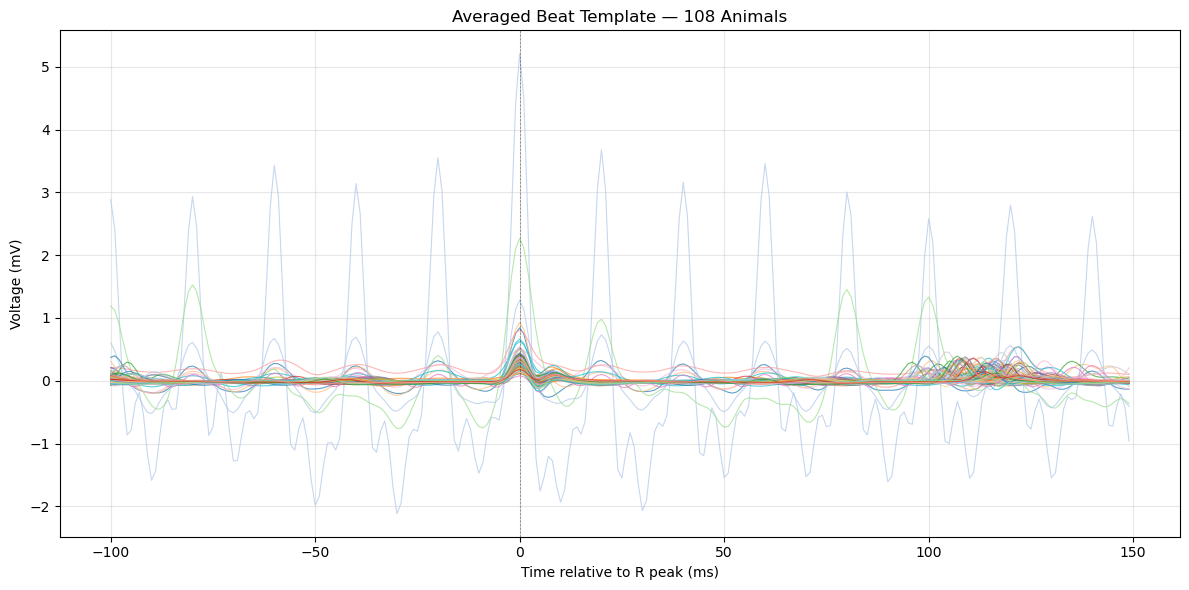

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
cmap = plt.cm.tab20
ids_sorted = sorted(templates.keys())
show_legend = len(ids_sorted) <= 20
for i, aid in enumerate(ids_sorted):
    tmpl, t_ms = templates[aid]
    ax.plot(t_ms, tmpl, color=cmap(i % 20), linewidth=0.8,
            alpha=0.7, label=f"Animal {aid}" if show_legend else None)
ax.axvline(0, color="k", linewidth=0.5, linestyle="--", alpha=0.5)
ax.set_xlabel("Time relative to R peak (ms)")
ax.set_ylabel("Voltage (mV)")
ax.set_title(f"Averaged Beat Template — {len(ids_sorted)} Animals")
if show_legend:
    ax.legend(loc="upper right", ncol=2, fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "07_all_averaged_beats.png", dpi=150)
plt.show()

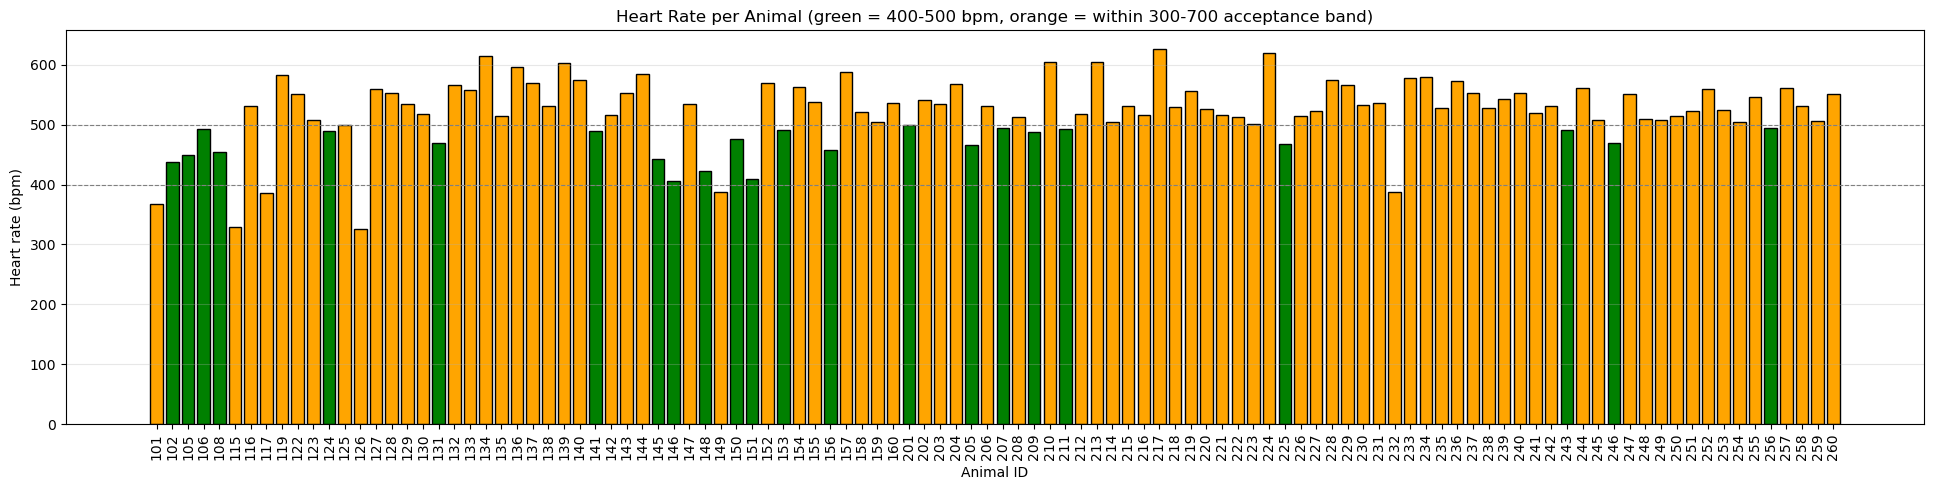

In [7]:
df_hr = pd.DataFrame(per_animal).sort_values("animal_id") if per_animal else pd.DataFrame()
if not df_hr.empty:
    colors = ["green" if HR_NORMAL_LOW <= hr <= HR_NORMAL_HIGH else "orange"
              for hr in df_hr["heart_rate_bpm"]]
    fig, ax = plt.subplots(figsize=(max(12, 0.18 * len(df_hr)), 5))
    ax.bar(df_hr["animal_id"].astype(str), df_hr["heart_rate_bpm"], color=colors, edgecolor="black")
    ax.axhline(HR_NORMAL_LOW,  color="gray", linestyle="--", linewidth=0.8)
    ax.axhline(HR_NORMAL_HIGH, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel("Animal ID")
    ax.set_ylabel("Heart rate (bpm)")
    ax.set_title(f"Heart Rate per Animal (green = {HR_NORMAL_LOW}-{HR_NORMAL_HIGH} bpm,"
                 f" orange = within 300-700 acceptance band)")
    ax.tick_params(axis="x", labelrotation=90)
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "08_heart_rates.png", dpi=150)
    plt.show()
else:
    print("No animals to plot.")

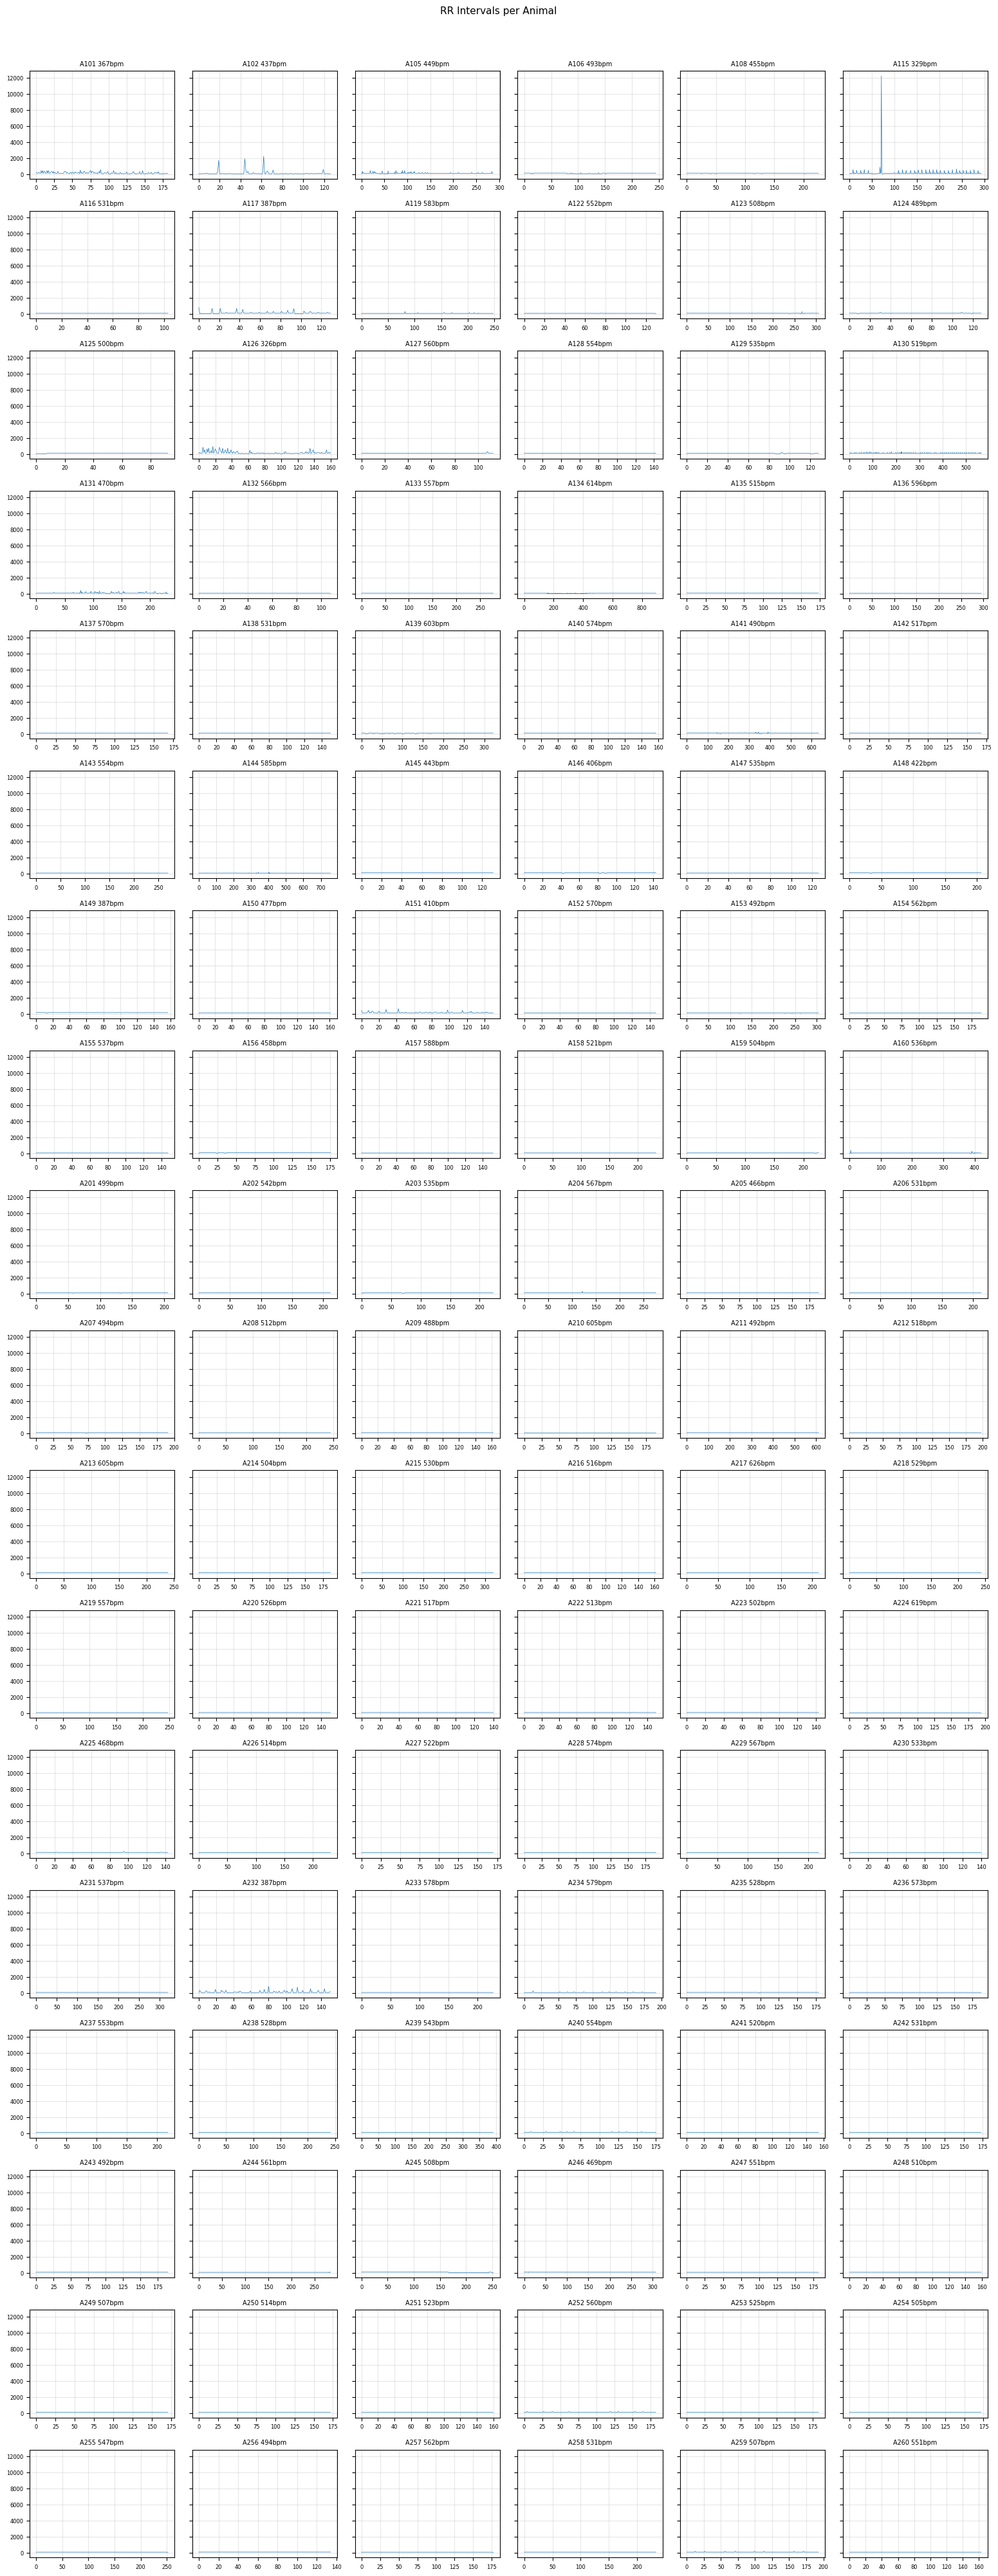

In [8]:
if per_animal:
    n = len(per_animal)
    ncols = 6 if n > 24 else 4
    nrows = max(1, int(np.ceil(n / ncols)))
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.6 * ncols, 2.2 * nrows), sharey=True)
    axes = np.array(axes).reshape(-1)
    sa = sorted(per_animal, key=lambda x: x["animal_id"])
    for i, a in enumerate(sa):
        ax = axes[i]
        ax.plot(a["rr_intervals_ms"], linewidth=0.5)
        ax.set_title(f"A{a['animal_id']} {a['heart_rate_bpm']:.0f}bpm", fontsize=7)
        ax.tick_params(labelsize=6)
        ax.grid(alpha=0.3)
    for j in range(len(sa), len(axes)):
        axes[j].axis("off")
    fig.suptitle("RR Intervals per Animal", y=1.01, fontsize=11)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "09_rr_all_animals.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No animals to plot.")

## Part 3 — Feature table

In [9]:
feature_cols = [
    "animal_id", "recording_date", "study_guess", "source_file",
    "n_beats", "heart_rate_bpm", "rr_mean_ms", "rr_std_ms",
    "r_amplitude_mv", "qrs_duration_ms",
    "j_wave_amplitude_mv", "t_wave_amplitude_mv",
    "rt_interval_ms", "qt_ms", "qtc_ms",
    "qt_std_ms", "qrs_std_ms", "r_amplitude_std_mv",
    "qtc_formula",
]
df = pd.DataFrame([{k: a.get(k) for k in feature_cols} for a in per_animal])
if not df.empty:
    df = df.sort_values("animal_id").reset_index(drop=True)
df.head(15) if not df.empty else "(empty)"

,animal_id,recording_date,study_guess,source_file,n_beats,heart_rate_bpm,rr_mean_ms,rr_std_ms,r_amplitude_mv,qrs_duration_ms,j_wave_amplitude_mv,t_wave_amplitude_mv,rt_interval_ms,qt_ms,qtc_ms,qt_std_ms,qrs_std_ms,r_amplitude_std_mv,qtc_formula
0,101,2024-11-01,acute,2024_11_01_101.txt,184,367.494478,163.267760,114.289921,0.843253,6.0,0.322732,0.267788,40.0,46.0,36.000424,17.088276,8.543785,0.965754,Mitchell
1,102,2024-11-01,acute,2024_11_01_102.txt,128,437.302726,137.204724,300.249350,5.214180,5.0,3.679942,3.462666,60.0,43.0,36.709961,11.116834,2.429344,2.787034,Mitchell
2,105,2024-11-01,acute,2024_11_01_105.txt,289,448.668017,133.729167,66.792384,0.312801,6.0,0.174092,0.055972,51.0,40.0,34.589710,26.275472,15.759884,0.092157,Mitchell
3,106,2024-11-01,acute,2024_11_01_106.txt,246,493.023880,121.697959,32.197753,0.926900,6.0,0.135047,0.147133,59.0,45.0,40.791612,12.411270,4.407925,0.677446,Mitchell
4,108,2024-11-01,acute,2024_11_01_108.txt,228,454.864242,131.907489,15.635655,0.518151,6.0,0.084050,0.009429,78.0,40.0,34.827738,1.563716,0.465773,0.043894,Mitchell
5,115,2024-11-13,acute,2024_11_13_115.txt,295,329.337963,182.183673,718.428224,2.263903,7.0,0.979757,1.452880,80.0,76.0,56.306543,17.717710,1.536388,1.369997,Mitchell
6,116,2024-11-14,acute,2024_11_14_116.txt,105,530.522020,113.096154,1.250392,0.249598,6.0,0.037648,0.047727,76.0,40.0,37.612835,19.648929,0.848878,0.030902,Mitchell
7,117,2024-11-14,acute,2024_11_14_117.txt,131,386.751289,155.138462,142.786975,0.806904,9.0,0.253048,0.236066,40.0,44.0,35.325876,32.778127,43.710382,1.199856,Mitchell
8,119,2024-11-01,acute,2024_11_01_119.txt,250,583.024390,102.911647,21.733174,0.246527,6.0,0.045403,0.046932,66.0,46.0,45.344599,14.697161,1.425746,0.058709,Mitchell
9,122,2024-11-14,acute,2024_11_14_122.txt,132,551.656373,108.763359,5.036531,0.404848,6.0,0.088798,0.009052,66.0,40.0,38.354708,22.356879,0.404073,0.036721,Mitchell


## Part 4 — Clustering

## PCA — Dimensionality Check (before clustering)
Run this before interpreting cluster results.
If 2 PCs explain <70% of variance, cluster shapes in the 2D plot are misleading.
Check the scree plot to find the natural dimensionality of the data.

Clustering feature matrix: 108 animals x 14 features


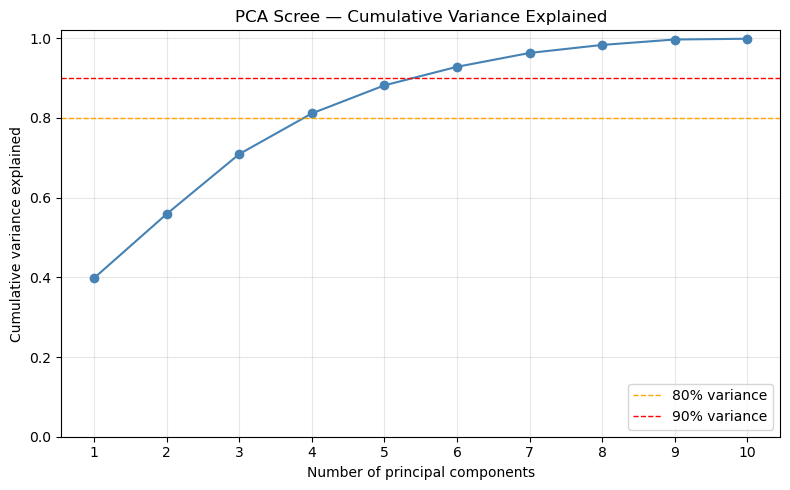

Variance explained:
  2 PCs ->  55.9% of total variance
  3 PCs ->  70.9% of total variance
  5 PCs ->  88.2% of total variance


C:\Users\Vishva\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


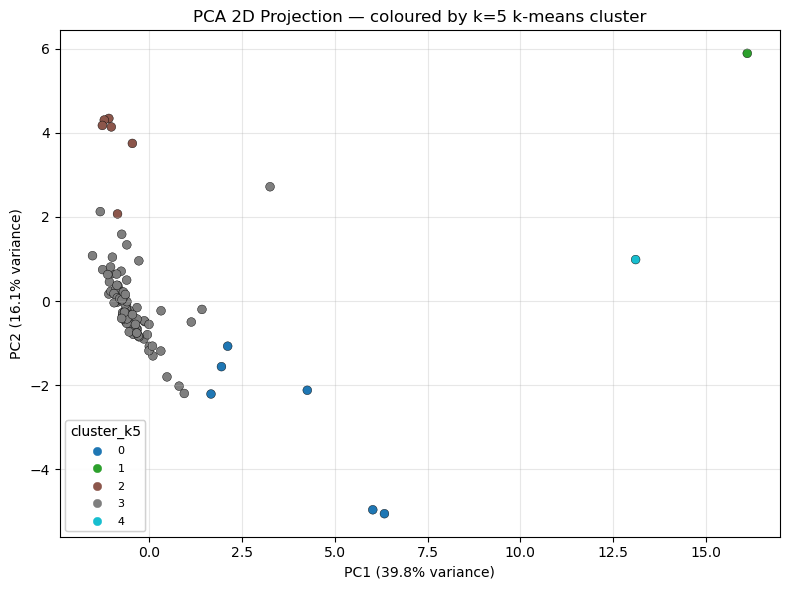

In [10]:
# Build the clustering feature matrix once (reused by the clustering cell below),
# then check dimensionality with PCA before interpreting any clusters.
if df.empty:
    print("No animals — skipping PCA.")
else:
    # Coefficient of variation of RR (beat-to-beat rhythm variability)
    df["rr_cv"] = df["rr_std_ms"] / df["rr_mean_ms"]

    cluster_feature_cols = [
        "heart_rate_bpm", "rr_mean_ms", "rr_std_ms",
        "r_amplitude_mv", "qrs_duration_ms",
        "j_wave_amplitude_mv", "t_wave_amplitude_mv",
        "qt_ms", "qtc_ms",
        "rt_interval_ms",        # already computed, now used in clustering
        "qt_std_ms",             # per-beat SD (Task 1)
        "qrs_std_ms",            # per-beat SD (Task 1)
        "r_amplitude_std_mv",    # per-beat SD (Task 1)
        "rr_cv",                 # coefficient of variation = rr_std_ms / rr_mean_ms
    ]
    X_raw    = df[cluster_feature_cols].copy()
    X_filled = X_raw.fillna(X_raw.median(numeric_only=True))
    X_scaled = StandardScaler().fit_transform(X_filled)
    n_features = X_scaled.shape[1]
    print(f"Clustering feature matrix: {X_scaled.shape[0]} animals x {n_features} features")

    # ---- Scree plot: cumulative variance explained, n_components 1..min(10,n) ----
    max_pc = min(10, n_features)
    pca_full = PCA(n_components=max_pc, random_state=42).fit(X_scaled)
    cum_var = np.cumsum(pca_full.explained_variance_ratio_)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(range(1, max_pc + 1), cum_var, marker="o", color="steelblue")
    ax.axhline(0.80, color="orange", linestyle="--", linewidth=1, label="80% variance")
    ax.axhline(0.90, color="red",    linestyle="--", linewidth=1, label="90% variance")
    ax.set_xlabel("Number of principal components")
    ax.set_ylabel("Cumulative variance explained")
    ax.set_title("PCA Scree — Cumulative Variance Explained")
    ax.set_xticks(range(1, max_pc + 1))
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.3); ax.legend(loc="lower right")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "11_pca_scree.png", dpi=150)
    plt.show()

    # ---- Variance explained by 2, 3, 5 components ----
    print("Variance explained:")
    for k in (2, 3, 5):
        if k <= max_pc:
            print(f"  {k} PCs -> {cum_var[k-1]*100:5.1f}% of total variance")

    # ---- 2D PCA scatter coloured by k=5 k-means ----
    pca2 = PCA(n_components=2, random_state=42)
    scores2 = pca2.fit_transform(X_scaled)
    pc1_pct, pc2_pct = pca2.explained_variance_ratio_[:2] * 100
    # preview labels for colour only; authoritative cluster_k5 computed in next
    # cell with the same X_scaled and KMeans seed (identical result)
    _preview_k5 = KMeans(n_clusters=5, n_init=10, random_state=42).fit_predict(X_scaled)

    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(scores2[:, 0], scores2[:, 1], c=_preview_k5,
                    cmap="tab10", s=40, edgecolor="k", linewidth=0.3)
    ax.set_xlabel(f"PC1 ({pc1_pct:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({pc2_pct:.1f}% variance)")
    ax.set_title("PCA 2D Projection — coloured by k=5 k-means cluster")
    ax.grid(alpha=0.3)
    ax.add_artist(ax.legend(*sc.legend_elements(), title="cluster_k5", loc="best", fontsize=8))
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "12_pca_scatter_2d.png", dpi=150)
    plt.show()


In [ ]:
# --- Labelled PCA figure for the Roisin meeting -------------------------------
# Re-runs 2-component PCA on the SAME X_scaled matrix built above; every point is
# labelled with its animal ID and statistical outliers are highlighted for review.
if df.empty:
    print("No animals — skipping Roisin PCA figure.")
else:
    _pca_r = PCA(n_components=2, random_state=42)
    _scores = _pca_r.fit_transform(X_scaled)
    _pc1_pct, _pc2_pct = _pca_r.explained_variance_ratio_[:2] * 100

    # Colour by k=5 k-means: use the saved column if present, otherwise the same
    # seed (identical labels to cluster_k5 computed in the clustering cell).
    if "cluster_k5" in df.columns:
        _labels_k5 = df["cluster_k5"].to_numpy()
    else:
        _labels_k5 = KMeans(n_clusters=5, n_init=10, random_state=42).fit_predict(X_scaled)
    _vmin, _vmax = int(_labels_k5.min()), int(_labels_k5.max())

    _animal_ids = df["animal_id"].to_numpy()

    # Outlier rule (pulled from data, not hardcoded): PC1 > 5 OR |PC2| > 3
    _is_outlier = (_scores[:, 0] > 5) | (np.abs(_scores[:, 1]) > 3)
    _outlier_ids = [int(a) for a in _animal_ids[_is_outlier]]

    fig, ax = plt.subplots(figsize=(14, 10))

    # Normal points (default size) then outliers (size 120, black edge); shared colour scale
    _norm = ~_is_outlier
    ax.scatter(_scores[_norm, 0], _scores[_norm, 1], c=_labels_k5[_norm],
               cmap="tab10", vmin=_vmin, vmax=_vmax, s=40, alpha=0.85)
    ax.scatter(_scores[_is_outlier, 0], _scores[_is_outlier, 1], c=_labels_k5[_is_outlier],
               cmap="tab10", vmin=_vmin, vmax=_vmax, s=120,
               edgecolor="black", linewidth=1.5, zorder=5)

    # Label every point with its animal ID, offset so labels don't sit on the dot
    for _x, _y, _aid in zip(_scores[:, 0], _scores[:, 1], _animal_ids):
        ax.text(_x + 0.15, _y + 0.1, str(int(_aid)), fontsize=7, alpha=0.9)

    ax.set_xlabel(f"PC1 ({_pc1_pct:.1f}% variance)", fontsize=12)
    ax.set_ylabel(f"PC2 ({_pc2_pct:.1f}% variance)", fontsize=12)
    ax.grid(alpha=0.3)

    # Title + smaller subtitle
    fig.suptitle(f"PCA of baseline ECG features — {len(df)} animals",
                 fontsize=15, fontweight="bold")
    ax.set_title("Point labels = animal ID. Highlighted points = statistical outliers in "
                 "PCA space. To be interpreted against treatment metadata (Roisin).",
                 fontsize=9)

    # Outlier text box, bottom-right corner
    _box = "Outliers to discuss: " + (", ".join(str(a) for a in _outlier_ids)
                                      if _outlier_ids else "none")
    ax.text(0.98, 0.02, _box, transform=ax.transAxes, fontsize=10, ha="right", va="bottom",
            bbox=dict(boxstyle="round", facecolor="wheat", edgecolor="black", alpha=0.9))

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(FIGURES_DIR / "pca_for_roisin.png", dpi=150)
    plt.show()

    print(f"PCA outliers (PC1 > 5 or |PC2| > 3): {_outlier_ids}")


C:\Users\Vishva\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Vishva\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Vishva\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Vishva\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Wi

k-means  k=2 sizes: {0: 106, 1: 2}
k-means  k=5 sizes: {3: 94, 0: 6, 2: 6, 1: 1, 4: 1}

cluster_k2 vs study_guess:
study_guess  acute  chronic
cluster_k2                 
0               46       60
1                2        0

Silhouette scores (k-means, k=2..8):
  k=2: silhouette = 0.783
  k=3: silhouette = 0.543
  k=4: silhouette = 0.532
  k=5: silhouette = 0.530
  k=6: silhouette = 0.215
  k=7: silhouette = 0.224
  k=8: silhouette = 0.224
  -> best k by silhouette: 2  (score 0.783)


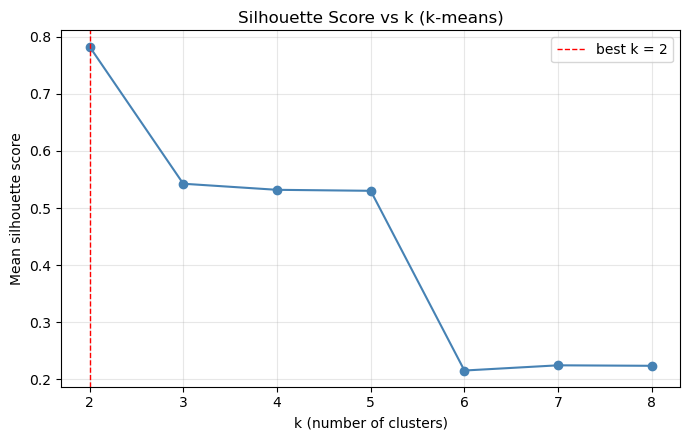


Hierarchical (Ward) k=2 sizes: {2: 106, 1: 2}
Hierarchical (Ward) k=5 sizes: {5: 99, 4: 5, 3: 2, 1: 1, 2: 1}

GMM k=2 sizes: {1: 103, 0: 5}
GMM k=5 sizes: {1: 70, 0: 27, 3: 6, 4: 4, 2: 1}

GMM BIC (k=2..8; lower = better fit):
  k=2: BIC = 528.4
  k=3: BIC = 368.2
  k=4: BIC = 143.2
  k=5: BIC = 122.4
  k=6: BIC = 411.3
  k=7: BIC = 480.8
  k=8: BIC = 605.7

=== Cluster-size profile at k=5 (largest -> smallest) ===
             kmeans  hierarchical  gmm
size_rank_1      94            99   70
size_rank_2       6             5   27
size_rank_3       6             2    6
size_rank_4       1             1    4
size_rank_5       1             1    1


C:\Users\Vishva\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Vishva\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Vishva\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Vishva\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Wi

In [12]:
if df.empty:
    print("No animals to cluster.")
else:
    # Feature matrix X_scaled and cluster_feature_cols are built in the PCA cell
    # above (14 features: morphology means + per-beat SDs + rr_cv + rt_interval_ms).

    # ---- 1) k-means: k=2 (acute/chronic style) and k=5 (treatment groups) ----
    def run_kmeans(k):
        if len(df) < k:
            return np.full(len(df), -1)
        return KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X_scaled)

    df["cluster_k2"] = run_kmeans(2)
    df["cluster_k5"] = run_kmeans(5)
    print("k-means  k=2 sizes:", dict(df["cluster_k2"].value_counts()))
    print("k-means  k=5 sizes:", dict(df["cluster_k5"].value_counts()))
    if "study_guess" in df.columns:
        print("\ncluster_k2 vs study_guess:")
        print(pd.crosstab(df["cluster_k2"], df["study_guess"]))

    # ---- 2) Silhouette sweep k=2..8 (k-means) to find optimal k ----
    print("\nSilhouette scores (k-means, k=2..8):")
    sil_ks, sil_scores = list(range(2, 9)), []
    for k in sil_ks:
        labels = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X_scaled)
        s = silhouette_score(X_scaled, labels)
        sil_scores.append(s)
        print(f"  k={k}: silhouette = {s:.3f}")
    best_k = sil_ks[int(np.argmax(sil_scores))]
    print(f"  -> best k by silhouette: {best_k}  (score {max(sil_scores):.3f})")

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(sil_ks, sil_scores, marker="o", color="steelblue")
    ax.axvline(best_k, color="red", linestyle="--", linewidth=1, label=f"best k = {best_k}")
    ax.set_xlabel("k (number of clusters)")
    ax.set_ylabel("Mean silhouette score")
    ax.set_title("Silhouette Score vs k (k-means)")
    ax.grid(alpha=0.3); ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "13_silhouette.png", dpi=150)
    plt.show()

    # ---- 3) Hierarchical clustering (Ward linkage) ----
    Z = linkage(X_scaled, method="ward")
    df["cluster_hier_k2"] = fcluster(Z, t=2, criterion="maxclust")
    df["cluster_hier_k5"] = fcluster(Z, t=5, criterion="maxclust")
    print("\nHierarchical (Ward) k=2 sizes:", dict(df["cluster_hier_k2"].value_counts()))
    print("Hierarchical (Ward) k=5 sizes:", dict(df["cluster_hier_k5"].value_counts()))

    # ---- 4) Gaussian Mixture Model ----
    df["cluster_gmm_k2"] = GaussianMixture(n_components=2, random_state=42).fit_predict(X_scaled)
    df["cluster_gmm_k5"] = GaussianMixture(n_components=5, random_state=42).fit_predict(X_scaled)
    print("\nGMM k=2 sizes:", dict(df["cluster_gmm_k2"].value_counts()))
    print("GMM k=5 sizes:", dict(df["cluster_gmm_k5"].value_counts()))
    print("\nGMM BIC (k=2..8; lower = better fit):")
    for k in range(2, 9):
        bic = GaussianMixture(n_components=k, random_state=42).fit(X_scaled).bic(X_scaled)
        print(f"  k={k}: BIC = {bic:.1f}")

    # ---- 5) Side-by-side comparison of cluster-size distributions at k=5 ----
    # Labels are not comparable across methods, so compare the SORTED size profile.
    def sizes_desc(col, k=5):
        v = sorted(df[col].value_counts().tolist(), reverse=True)
        return (v + [0] * k)[:k]
    comp = pd.DataFrame({
        "kmeans":       sizes_desc("cluster_k5"),
        "hierarchical": sizes_desc("cluster_hier_k5"),
        "gmm":          sizes_desc("cluster_gmm_k5"),
    }, index=[f"size_rank_{i+1}" for i in range(5)])
    print("\n=== Cluster-size profile at k=5 (largest -> smallest) ===")
    print(comp.to_string())


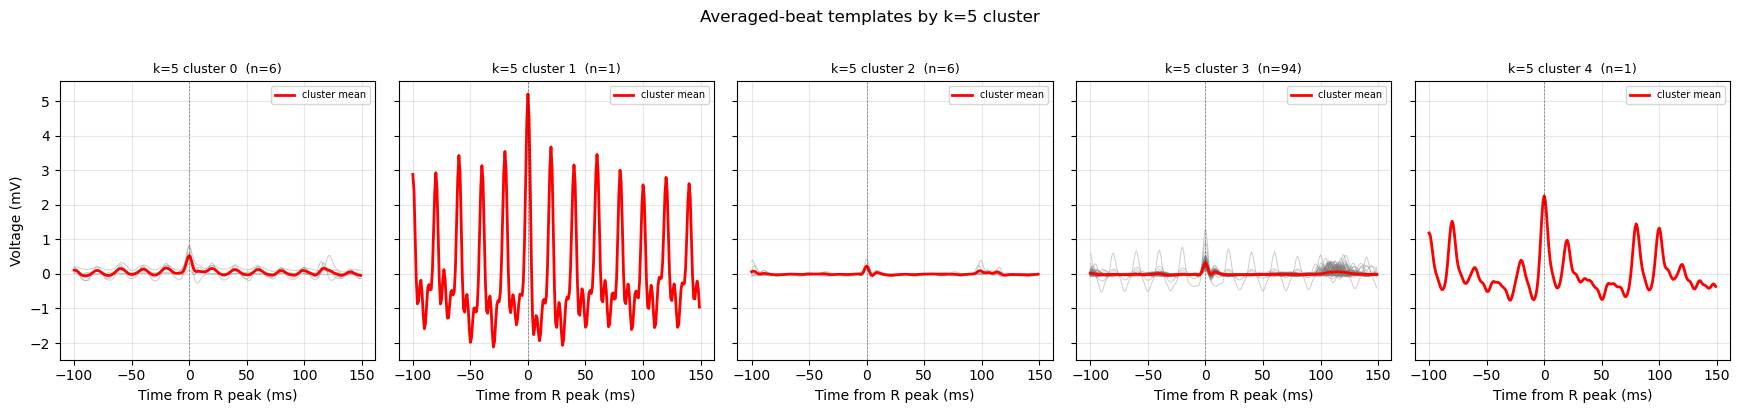

In [13]:
if not df.empty and templates:
    clusters_present = sorted(c for c in df["cluster_k5"].unique() if c >= 0)
    n_panels = max(len(clusters_present), 1)
    fig, axes = plt.subplots(1, n_panels, figsize=(3.5 * n_panels, 4),
                             sharey=True, squeeze=False)
    axes = axes[0]
    last_t_ms = None
    for ax, c in zip(axes, clusters_present):
        members = df.loc[df["cluster_k5"] == c, "animal_id"].tolist()
        stack = []
        for aid in members:
            if aid in templates:
                tmpl, t_ms = templates[aid]
                ax.plot(t_ms, tmpl, color="gray", alpha=0.4, linewidth=0.7)
                stack.append(tmpl); last_t_ms = t_ms
        if stack and last_t_ms is not None:
            centroid = np.mean(np.vstack(stack), axis=0)
            ax.plot(last_t_ms, centroid, color="red", linewidth=2.0, label="cluster mean")
        ax.set_title(f"k=5 cluster {c}  (n={len(members)})", fontsize=9)
        ax.set_xlabel("Time from R peak (ms)")
        ax.axvline(0, color="k", linewidth=0.5, linestyle="--", alpha=0.5)
        ax.grid(alpha=0.3); ax.legend(fontsize=7)
    axes[0].set_ylabel("Voltage (mV)")
    fig.suptitle("Averaged-beat templates by k=5 cluster", y=1.02)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "10_cluster_beats.png", dpi=150, bbox_inches="tight")
    plt.show()

## Part 5 — Master CSV

In [14]:
if not df.empty:
    out_cols = [
        "animal_id", "recording_date", "study_guess",
        "n_beats", "heart_rate_bpm", "rr_mean_ms", "rr_std_ms",
        "r_amplitude_mv", "qrs_duration_ms",
        "j_wave_amplitude_mv", "t_wave_amplitude_mv",
        "qt_ms", "qtc_ms", "qtc_formula",
        "qt_std_ms", "qrs_std_ms", "r_amplitude_std_mv", "rr_cv",
        "cluster_k2", "cluster_k5",
        "cluster_hier_k2", "cluster_hier_k5",
        "cluster_gmm_k2", "cluster_gmm_k5",
    ]
    summary = df[out_cols].copy()
    summary["recording_date"] = pd.to_datetime(summary["recording_date"]).dt.date
    csv_path = OUTPUTS_DIR / "all_animals_features.csv"
    summary.to_csv(csv_path, index=False)
    print(f"Saved: {csv_path}")
    print(f"Rows : {len(summary)}")
    summary.head(20)
else:
    print("No animals to save.")

Saved: C:\Users\Vishva\Downloads\ecg_cardiotoxicity_project\outputs\all_animals_features.csv
Rows : 108


## Final summary

In [15]:
print("=" * 60)
print("NOTEBOOK 02 — SUMMARY")
print("=" * 60)
status_counts = pd.Series([r["status"] for r in rows_all]).value_counts()
print(f"Total files found      : {len(files)}")
for status, n in status_counts.items():
    print(f"  {status:<20} : {n}")

if per_animal:
    hrs = pd.Series([a["heart_rate_bpm"] for a in per_animal])
    print(f"\nHR (bpm)        : min {hrs.min():.0f}   mean {hrs.mean():.0f}   max {hrs.max():.0f}")
    print(f"In 400-500 bpm  : {((hrs >= HR_NORMAL_LOW) & (hrs <= HR_NORMAL_HIGH)).sum()}/{len(hrs)}")

if needs_review:
    print("\nNeeds manual review (HR outside 300-700 bpm):")
    for a in needs_review:
        print(f"   - animal {a['animal_id']:>4}  HR {a['heart_rate_bpm']:6.1f} bpm  ({a['source_file']})")

failed = [r for r in rows_all if r["status"].startswith("FAILED")]
if failed:
    print("\nFailed files (ask Roisin about these):")
    for r in failed[:40]:
        print(f"   - {r['file']}: {r['status']} — {r['rule_used']}")
    if len(failed) > 40:
        print(f"   ... and {len(failed) - 40} more (see outputs/per_file_audit.csv)")

print("\nFigures saved to:", FIGURES_DIR)
print("Feature CSV     :", OUTPUTS_DIR / "all_animals_features.csv")
print("Per-file audit  :", OUTPUTS_DIR / "per_file_audit.csv")

NOTEBOOK 02 — SUMMARY
Total files found      : 116
  OK                   : 108
  NEEDS_REVIEW         : 6
  FAILED_PEAKS         : 2

HR (bpm)        : min 326   mean 518   max 626
In 400-500 bpm  : 23/108

Needs manual review (HR outside 300-700 bpm):
   - animal  107  HR  140.3 bpm  (2024_11_01_107.txt)
   - animal  114  HR  265.8 bpm  (2024_11_114.txt)
   - animal  111  HR  263.6 bpm  (2024_11_13_111.txt)
   - animal  112  HR  175.4 bpm  (2024_11_13_112.txt)
   - animal  113  HR   85.2 bpm  (2024_11_13_113.txt)
   - animal  121  HR  135.7 bpm  (2024_11_14_121.txt)

Failed files (ask Roisin about these):
   - 2024_11_01_109.txt: FAILED_PEAKS — C_long_baseline
   - 2024_11_14_120.txt: FAILED_PEAKS — A_same_*

Figures saved to: C:\Users\Vishva\Downloads\ecg_cardiotoxicity_project\outputs\figures
Feature CSV     : C:\Users\Vishva\Downloads\ecg_cardiotoxicity_project\outputs\all_animals_features.csv
Per-file audit  : C:\Users\Vishva\Downloads\ecg_cardiotoxicity_project\outputs\per_file_